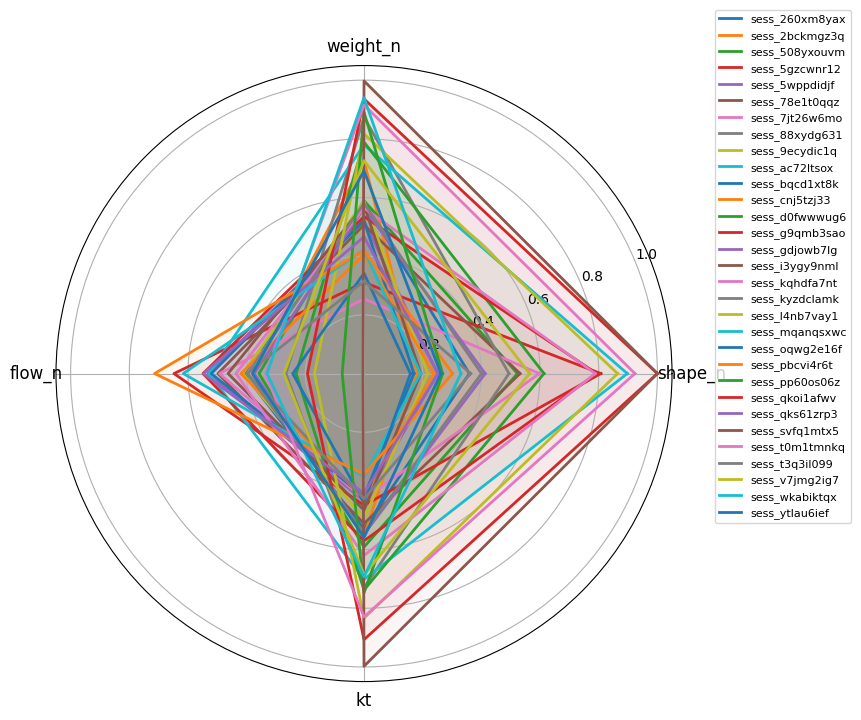

In [ ]:
# =====================================
# SparkBody 完整分析 v2 - 32人強制鎖定版
# IEEE TAC Affective Intelligence & Art Design
# =====================================

import io, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.animation as animation
import seaborn as sns
from pathlib import Path

# =====================================================
# ⚙️ 設定區
# =====================================================
TSV_PATHS = [
    r"C:\Users\user\posefireworks\analysis_lab\raw_data\SparkBodyDaTa V.2 -  Sheet330.tsv",
]

FFMPEG_EXE = r"C:\Users\user\posefireworks\analysis_lab\ffmpeg.exe"
PLOTS_DIR  = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# --- 32人強制名單 (自動處理副檔名) ---
RAW_LIST = [
    "sess_1ho7dln6j", "sess_qkoi1afwv", "sess_v7jmg2ig7", "sess_508yxouvm",
    "sess_mqanqsxwc", "sess_kqhdfa7nt", "sess_d0fwwwug6", "sess_ytlau6ief",
    "sess_cnj5tzj33", "sess_88xydg631", "sess_g9qmb3sao", "sess_gdjowb7lg",
    "sess_78e1t0qqz", "sess_9ecydic1q", "sess_qks61zrp3", "sess_wkabiktqx",
    "sess_ac72ltsox", "sess_kyzdclamk", "sess_pp60os06z", "sess_t3q3il099",
    "sess_i3ygy9nml", "sess_7jt26w6mo", "sess_2bckmgz3q", "sess_pbcvi4r6t",
    "sess_bqcd1xt8k", "sess_5wppdidjf", "sess_oqwg2e16f", "sess_5gzcwnr12",
    "sess_svfq1mtx5", "sess_t0m1tmnkq", "sess_l4nb7vay1", "sess_260xm8yax"
]
TARGET_SESSIONS = [s.replace(".mp4", "") for s in RAW_LIST]

LMA_COLS   = ["shape_n", "weight_n", "flow_n", "kt"]
ACTIVITIES = ["Heart", "Victory", "Fireworks_Explosion", "Gull_Flap", "Dance_Continuous"]
COLORS     = ["#E63946", "#457B9D", "#F4A261", "#2A9D8F", "#8338EC"]
ACT_COLOR  = dict(zip(ACTIVITIES, COLORS))
COORD_COLS = ["lh_x","lh_y","rh_x","rh_y","ls_x","ls_y","rs_x","rs_y"]

# =====================================================
# 1️⃣ 讀取與合併
# =====================================================
dfs = []
for path in TSV_PATHS:
    try:
        with open(path, encoding="utf-8") as f:
            raw = f.read()
        lines = [l for l in raw.split("\n") if "\t" in l]
        df_tmp = pd.read_csv(io.StringIO("\n".join(lines)), sep="\t", header=None,
                             names=["sessionId","userId","timestamp","mode","activity"] + LMA_COLS + ["baselineReady"] + COORD_COLS + ["note"])
        dfs.append(df_tmp)
        print(f"✅ 載入: {Path(path).name} ({len(df_tmp)} 筆)")
    except Exception as e:
        print(f"❌ 無法載入: {path} ({e})")

df_all = pd.concat(dfs, ignore_index=True)

# 轉型與修復警告
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], format='ISO8601', errors="coerce", utc=True)
for c in LMA_COLS + COORD_COLS:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

# =====================================================
# 2️⃣ 強制篩選 32 人並生成摘要
# =====================================================
df_range = df_all[df_all["sessionId"].isin(TARGET_SESSIONS)].copy()

session_info = []
for sid in TARGET_SESSIONS:
    sub = df_range[df_range["sessionId"] == sid]
    if sub.empty:
        session_info.append({"status": "❌ 找不到", "sessionId": sid, "台灣開始": "-", "筆數": 0, "KT均值": "-"})
        continue
    
    t_start_tw = sub["timestamp"].min() + pd.Timedelta(hours=8)
    kt_m = sub["kt"].mean()
    session_info.append({
        "status": "✅ 鎖定",
        "sessionId": sid,
        "台灣開始": str(t_start_tw)[11:16],
        "筆數": len(sub),
        "KT均值": round(kt_m, 3) if pd.notna(kt_m) else "-"
    })

df_sessions = pd.DataFrame(session_info)
valid_ids = df_sessions[df_sessions["筆數"] > 0]["sessionId"].tolist()

print("\n--- 32人名單對齊狀態 ---")
print(df_sessions.to_string(index=False))

# 最終清洗供後續 4 張圖使用
df = df_range[df_range["sessionId"].isin(valid_ids)].dropna(subset=COORD_COLS).copy().reset_index(drop=True)
df_act = df[df["activity"].isin(ACTIVITIES)].copy()

n_valid = len(df)
n_sessions = df["sessionId"].nunique()

# =====================================================
# 📊 5️⃣~8️⃣ 原版四張大圖 (修復語法警告)
# =====================================================

# --- 圖1：盒鬚圖 ---
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle("LMA Indicators by Activity (Target 32)", fontsize=15, fontweight="bold")
for ax, col in zip(axes.flat, LMA_COLS):
    data = [df_act[df_act["activity"] == a][col].dropna().values for a in ACTIVITIES]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(ACTIVITIES)+1))
    ax.set_xticklabels([a.replace("_", "\n") for a in ACTIVITIES], fontsize=9)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel("Normalized Value"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(PLOTS_DIR / "fig1_lma_boxplot.png", dpi=300)
plt.show()

# --- 圖2：熱力圖 ---
heatmap_data = df_act.groupby("activity", observed=True)[LMA_COLS].mean().reindex(ACTIVITIES)
fig2, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Mean LMA Indicators per Activity", fontsize=13, fontweight="bold")
plt.savefig(PLOTS_DIR / "fig2_lma_heatmap.png", dpi=300)
plt.show()

# --- 圖3：雷達圖 ---
session_means = df.groupby("sessionId", observed=True)[LMA_COLS].mean()
N = len(LMA_COLS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
fig3, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
cmap = plt.get_cmap("tab10")
for i, (sid, row) in enumerate(session_means.iterrows()):
    values = row[LMA_COLS].tolist() + [row[LMA_COLS[0]]]
    ax.plot(angles, values, linewidth=2, color=cmap(i % 10), label=sid)
    ax.fill(angles, values, alpha=0.05, color=cmap(i % 10))
ax.set_xticks(angles[:-1]); ax.set_xticklabels(LMA_COLS, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.savefig(PLOTS_DIR / "fig3_lma_radar.png", dpi=300)
plt.show()

# --- 圖4：時序圖 ---
sessions = df["sessionId"].unique()
fig4, axes = plt.subplots(len(sessions), 1, figsize=(14, 3*len(sessions)), squeeze=False)
for i, sid in enumerate(sessions):
    ax = axes[i, 0]
    sdf = df[df["sessionId"] == sid].reset_index(drop=True)
    ax.plot(sdf.index, sdf["kt"], color="#457B9D", linewidth=2)
    ax.fill_between(sdf.index, sdf["kt"], alpha=0.15, color="#457B9D")
    for idx, row in sdf.iterrows():
        if row["activity"] in ACT_COLOR:
            ax.axvline(idx, color=ACT_COLOR[row["activity"]], alpha=0.3, linewidth=1)
    ax.set_title(f"Session: {sid}", fontsize=9); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig4_kt_timeseries.png", dpi=300)
plt.show()

# =====================================================
# 🎬 9️⃣ 動畫 MP4 (原版大規格)
# =====================================================
def export_session_mp4(sid):
    vsdf = df[df["sessionId"] == sid].copy().reset_index(drop=True)
    if vsdf.empty: return
    fig_a, ax_a = plt.subplots(figsize=(5, 5))
    ax_a.set_xlim(1, 0); ax_a.set_ylim(1, 0)
    line_l, = ax_a.plot([], [], "g-o", lw=4, label="Left Arm")
    line_r, = ax_a.plot([], [], "r-o", lw=4, label="Right Arm")
    line_s, = ax_a.plot([], [], "b-",  lw=4, alpha=0.5, label="Shoulders")
    act_text = ax_a.text(0.05, 0.05, "", transform=ax_a.transAxes, fontsize=9, color="gray")
    
    def update(frame):
        row = vsdf.iloc[frame]
        line_l.set_data([row.ls_x, row.lh_x], [row.ls_y, row.lh_y])
        line_r.set_data([row.rs_x, row.rh_x], [row.rs_y, row.rh_y])
        line_s.set_data([row.ls_x, row.rs_x], [row.ls_y, row.rs_y])
        act_text.set_text(f"{row.activity} kt={row.kt:.2f}")
        return line_l, line_r, line_s, act_text

    ani = animation.FuncAnimation(fig_a, update, frames=len(vsdf), interval=200, blit=True)
    writer = animation.FFMpegWriter(fps=5, executable=FFMPEG_EXE)
    ani.save(PLOTS_DIR / f"{sid}.mp4", writer=writer)
    plt.close(fig_a)

print("\n🎬 開始產出 MP4...")
for sid in valid_ids:
    export_session_mp4(sid)
    print(f"  > {sid} Done")

print(f"\n✅ 任務完成！所有圖 1-4 與 32 份影片已存於 {PLOTS_DIR.resolve()}")